In [1]:
import ase 
from ase import io
from ase.visualize import view
from pathlib import Path
import matplotlib.pyplot as plt

import mmml
import ase
import numpy as np
from ase import io
from ase.constraints import FixInternals
from ase.optimize import BFGS
from mmml.models.EF.ase_calc_EF import AseCalculatorEF

from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3

patch_chemcoord_for_pandas3()

import ase
from ase import io as ase_io
from ase.visualize import view
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns


import chemcoord as cc


CUDA graph capture is not supported in this JAX version
JAX devices: [CudaDevice(id=0)]


E0526 14:14:28.471955 3655206 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 39.10GiB (41980758784 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [2]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [3]:
mol = ase.io.read("mol_a.xyz")
view(mol, viewer="x3d")

In [4]:
EF = np.array([0,0,0])


CONFIG = "/scicore/home/meuwly/boitti0000/ckpts/propox_ef_ptT_run2/config-cd423da4-7e03-44f5-b149-5c19d583e011.json"
PARAMS = "/scicore/home/meuwly/boitti0000/ckpts/propox_ef_ptT_run2/params-cd423da4-7e03-44f5-b149-5c19d583e011.json"
calc = AseCalculatorEF(
    PARAMS,
    config_path=CONFIG,
    electric_field=EF,  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)
print(calc)

In [5]:
mol.calc = calc

In [6]:
import numpy as np
from ase import Atoms, units
from ase.io import read
from ase.io.trajectory import Trajectory
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
# from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet  # for NVE


from ase.optimize import FIRE
opt = FIRE(mol, maxstep=0.04)
opt.run(fmax=0.05, steps=500)




print(mol.get_potential_energy(), "eV")
print(np.max(np.abs(mol.get_forces())), "eV/Å")


      Step     Time          Energy          fmax
FIRE:    0 14:14:51      -44.273132        2.119400
FIRE:    1 14:14:51      -44.326664        0.526326
FIRE:    2 14:14:51      -44.305428        1.797524
FIRE:    3 14:14:51      -44.324665        1.307396
FIRE:    4 14:14:51      -44.347580        0.483925
FIRE:    5 14:14:52      -44.341530        0.540683
FIRE:    6 14:14:52      -44.338032        0.502326
FIRE:    7 14:14:52      -44.341461        0.432692
FIRE:    8 14:14:52      -44.345314        0.333903
FIRE:    9 14:14:52      -44.345325        0.248589
FIRE:   10 14:14:52      -44.350414        0.215427
FIRE:   11 14:14:52      -44.354023        0.218589
FIRE:   12 14:14:52      -44.355305        0.224535
FIRE:   13 14:14:52      -44.358349        0.289016
FIRE:   14 14:14:52      -44.352661        0.307758
FIRE:   15 14:14:52      -44.348602        0.278934
FIRE:   16 14:14:52      -44.354645        0.190642
FIRE:   17 14:14:52      -44.349850        0.117961
FIRE:   18 14:

In [25]:
# Velocities + thermostat
T_K = 300.0
dt_fs = 0.5
NSTEPS=200_000


R = mol.get_positions()
R = R - R.mean(axis=0)
mol.set_positions(R)


MaxwellBoltzmannDistribution(mol, temperature_K=T_K, rng=np.random.default_rng(42))
# dyn = Langevin(
#     atoms,
#     timestep=dt_fs * units.fs,
#     temperature_K=T_K,
#     friction=0.01 / units.fs,   # 1/fs
# )
dyn = VelocityVerlet(mol, timestep=dt_fs * units.fs)  # NVE
traj = Trajectory("md01.traj", "w", mol)
dyn.attach(traj.write, interval=2)
dyn.run(NSTEPS)
traj.close()

In [26]:
traj = ase.io.read("md01.traj", index=":")
Es = [_.get_potential_energy() for _ in traj]

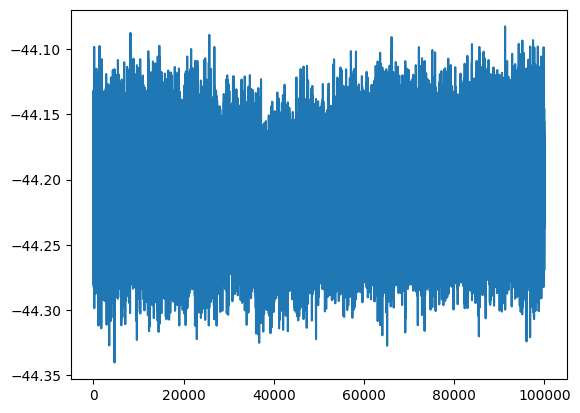

In [27]:
plt.plot(Es)

In [24]:
view(traj[-1], viewer="x3d")

In [41]:

# dih_frames.npz
atoms = io.read("mol_a.xyz")


calc = AseCalculatorEF(
    PARAMS,
    CONFIG,
    electric_field=[0,0,0],  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)

atoms.calc = calc

# set up optimizer
opt = BFGS(
    atoms,
    trajectory="opt_bfgs.traj",   # optional: saves optimization path
    logfile="-",                  # prints progress in notebook
    maxstep=0.04,                 # conservative step size (A)
)
# run until converged
opt.run(fmax=0.003, steps=1000)
print("Converged geometry:")
print(atoms.get_positions())
print("Final energy (eV):", atoms.get_potential_energy())
print("Final max |F| (eV/A):", np.max(np.abs(atoms.get_forces())))

from mmml.models.EF.ase_calc_EF import AseCalculatorEF
from mmml.models.EF.calc_spectra import (
    compute_normal_modes, compute_ir, compute_raman, compute_vcd
)
import ase, numpy as np

H = calc.get_hessian(atoms)                    # (N,3,N,3)
APT = calc.get_atomic_polar_tensor(atoms)      # dμ/dR
freq, evec_mw, evec_cart = compute_normal_modes(H, atoms.get_masses())
ir_int, _ = compute_ir(APT, evec_cart)
raman_act, _ = compute_raman(calc, atoms, evec_cart, freq)  # optional
AAT, _ = calc.get_aat_born(atoms)              # or get_aat_ml_charges / get_aat_nuclear
vcd_rot, _, _ = compute_vcd(APT, AAT, evec_cart)

# Cell 3: broaden sticks into smooth spectra + nice plot
def lorentzian(x, x0, gamma):
    return gamma / (np.pi * ((x - x0)**2 + gamma**2))

def broaden_spectrum(freq_axis, mode_freqs, mode_intensities, gamma=10.0, min_freq=20.0):
    y = np.zeros_like(freq_axis, dtype=float)
    for f, I in zip(mode_freqs, mode_intensities):
        if np.isfinite(f) and f > min_freq:
            y += I * lorentzian(freq_axis, f, gamma)
    return y

# plotting axis
fmin, fmax, npts = 10.0, 4000.0, 4000
freq_axis = np.linspace(fmin, fmax, npts)

# spectra (arb. units, normalized for display)
ir_spec = broaden_spectrum(freq_axis, freq, ir_int, gamma=12.0)
raman_spec = broaden_spectrum(freq_axis, freq, raman_act, gamma=12.0)
vcd_spec = broaden_spectrum(freq_axis, freq, vcd_rot, gamma=12.0)

def safe_norm(y):
    m = np.max(np.abs(y))
    return y / m if m > 0 else y

ir_n = safe_norm(ir_spec)
raman_n = safe_norm(raman_spec)
vcd_n = safe_norm(vcd_spec)




      Step     Time          Energy          fmax
BFGS:    0 13:55:35      -44.273136        2.118827
BFGS:    1 13:55:35      -44.326397        1.204907
BFGS:    2 13:55:35      -44.338150        0.379187
BFGS:    3 13:55:35      -44.343285        0.243085
BFGS:    4 13:55:36      -44.354057        0.285629
BFGS:    5 13:55:36      -44.354500        0.114213
BFGS:    6 13:55:36      -44.359833        0.102758
BFGS:    7 13:55:36      -44.360664        0.154782
BFGS:    8 13:55:36      -44.363243        0.111192
BFGS:    9 13:55:36      -44.359821        0.049666
BFGS:   10 13:55:36      -44.362907        0.038027
BFGS:   11 13:55:36      -44.360584        0.052906
BFGS:   12 13:55:36      -44.361191        0.040491
BFGS:   13 13:55:36      -44.361275        0.021967
BFGS:   14 13:55:36      -44.358715        0.023976
BFGS:   15 13:55:36      -44.355286        0.030971
BFGS:   16 13:55:36      -44.363930        0.022769
BFGS:   17 13:55:36      -44.359642        0.016373
BFGS:   18 13:

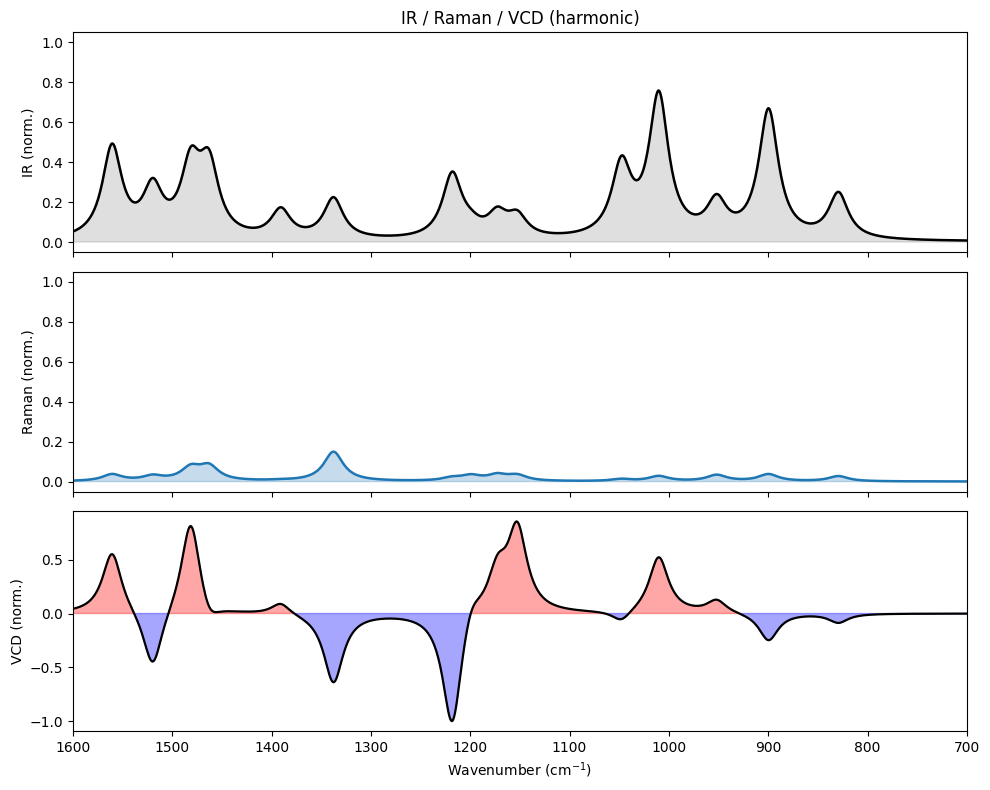

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(freq_axis, ir_n, lw=1.8, color="black")
axes[0].fill_between(freq_axis, 0, ir_n, alpha=0.25, color="gray")
axes[0].set_ylabel("IR (norm.)")
axes[0].set_title("IR / Raman / VCD (harmonic)")

axes[1].plot(freq_axis, raman_n, lw=1.8, color="tab:blue")
axes[1].fill_between(freq_axis, 0, raman_n, alpha=0.25, color="tab:blue")
axes[1].set_ylabel("Raman (norm.)")

axes[2].plot(freq_axis, vcd_n, lw=1.6, color="k")
axes[2].fill_between(freq_axis, 0, vcd_n, where=(vcd_n >= 0), color="red", alpha=0.35)
axes[2].fill_between(freq_axis, 0, vcd_n, where=(vcd_n < 0), color="blue", alpha=0.35)
axes[2].set_ylabel("VCD (norm.)")
axes[2].set_xlabel(r"Wavenumber (cm$^{-1}$)")

# # usual spectroscopy convention
for ax in axes:
    ax.invert_xaxis()
    # ax.grid(alpha=0.2)
    ax.set_xlim(1600, 700)



plt.tight_layout()

plt.savefig("test_a.pdf", bbox_inches="tight")
plt.show()

      Step     Time          Energy          fmax
BFGS:    0 13:47:00      -44.273994        2.120243
BFGS:    1 13:47:00      -44.317703        1.214269
BFGS:    2 13:47:00      -44.336037        0.373180
BFGS:    3 13:47:00      -44.346962        0.247095
BFGS:    4 13:47:00      -44.358150        0.279530
BFGS:    5 13:47:00      -44.353161        0.117633
BFGS:    6 13:47:00      -44.362324        0.108298
BFGS:    7 13:47:00      -44.363693        0.152538
BFGS:    8 13:47:00      -44.361412        0.111019
BFGS:    9 13:47:00      -44.362183        0.053389
BFGS:   10 13:47:00      -44.357998        0.040098
BFGS:   11 13:47:00      -44.363098        0.053108
BFGS:   12 13:47:00      -44.362415        0.037468
BFGS:   13 13:47:00      -44.362289        0.024133
BFGS:   14 13:47:00      -44.365719        0.023970
BFGS:   15 13:47:00      -44.366165        0.037891
BFGS:   16 13:47:00      -44.367413        0.021579
BFGS:   17 13:47:00      -44.362198        0.016175
BFGS:   18 13:

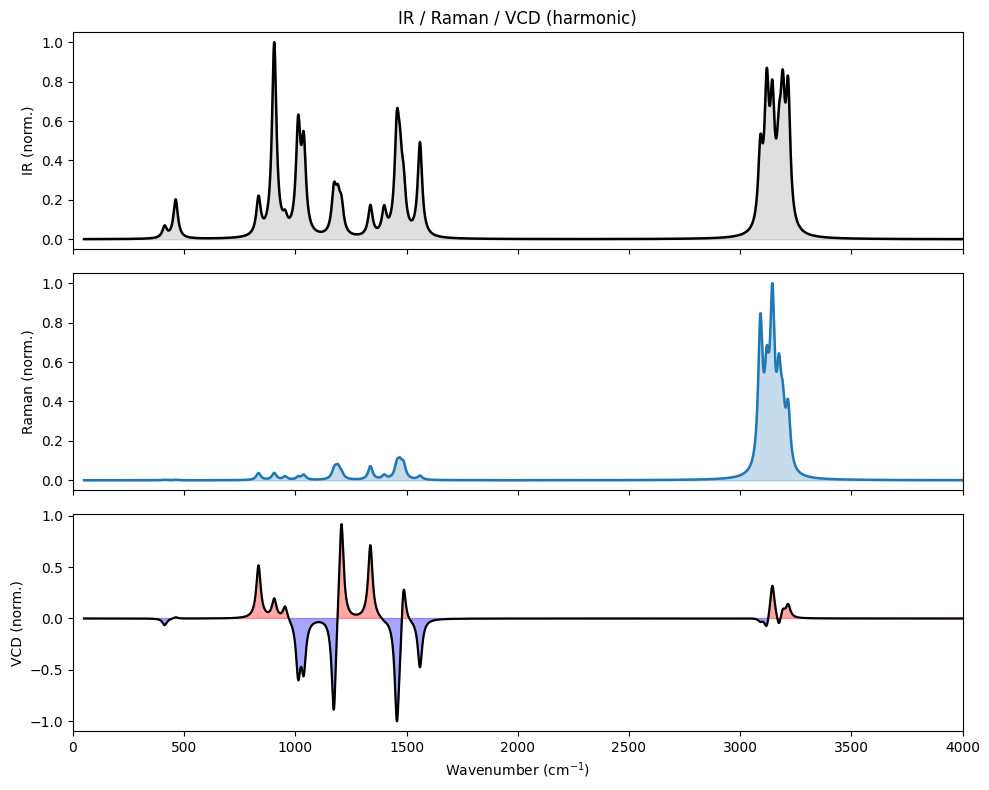

In [33]:

# dih_frames.npz
atoms = io.read("mol_b.xyz")


calc = AseCalculatorEF(
    PARAMS,
    CONFIG,
    electric_field=[0,0,0],  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)

atoms.calc = calc

# set up optimizer
opt = BFGS(
    atoms,
    trajectory="opt_bfgs_b.traj",   # optional: saves optimization path
    logfile="-",                  # prints progress in notebook
    maxstep=0.04,                 # conservative step size (A)
)
# run until converged
opt.run(fmax=0.003, steps=1000)
print("Converged geometry:")
print(atoms.get_positions())
print("Final energy (eV):", atoms.get_potential_energy())
print("Final max |F| (eV/A):", np.max(np.abs(atoms.get_forces())))

from mmml.models.EF.ase_calc_EF import AseCalculatorEF
from mmml.models.EF.calc_spectra import (
    compute_normal_modes, compute_ir, compute_raman, compute_vcd
)
import ase, numpy as np

H = calc.get_hessian(atoms)                    # (N,3,N,3)
APT = calc.get_atomic_polar_tensor(atoms)      # dμ/dR
freq, evec_mw, evec_cart = compute_normal_modes(H, atoms.get_masses())
ir_int, _ = compute_ir(APT, evec_cart)
raman_act, _ = compute_raman(calc, atoms, evec_cart, freq)  # optional
AAT, _ = calc.get_aat_born(atoms)              # or get_aat_ml_charges / get_aat_nuclear
vcd_rot, _, _ = compute_vcd(APT, AAT, evec_cart)

# Cell 3: broaden sticks into smooth spectra + nice plot
def lorentzian(x, x0, gamma):
    return gamma / (np.pi * ((x - x0)**2 + gamma**2))

def broaden_spectrum(freq_axis, mode_freqs, mode_intensities, gamma=10.0, min_freq=20.0):
    y = np.zeros_like(freq_axis, dtype=float)
    for f, I in zip(mode_freqs, mode_intensities):
        if np.isfinite(f) and f > min_freq:
            y += I * lorentzian(freq_axis, f, gamma)
    return y

# plotting axis
fmin, fmax, npts = 50.0, 4000.0, 4000
freq_axis = np.linspace(fmin, fmax, npts)

# spectra (arb. units, normalized for display)
ir_spec = broaden_spectrum(freq_axis, freq, ir_int, gamma=12.0)
raman_spec = broaden_spectrum(freq_axis, freq, raman_act, gamma=12.0)
vcd_spec = broaden_spectrum(freq_axis, freq, vcd_rot, gamma=12.0)

def safe_norm(y):
    m = np.max(np.abs(y))
    return y / m if m > 0 else y

ir_n = safe_norm(ir_spec)
raman_n = safe_norm(raman_spec)
vcd_n = safe_norm(vcd_spec)




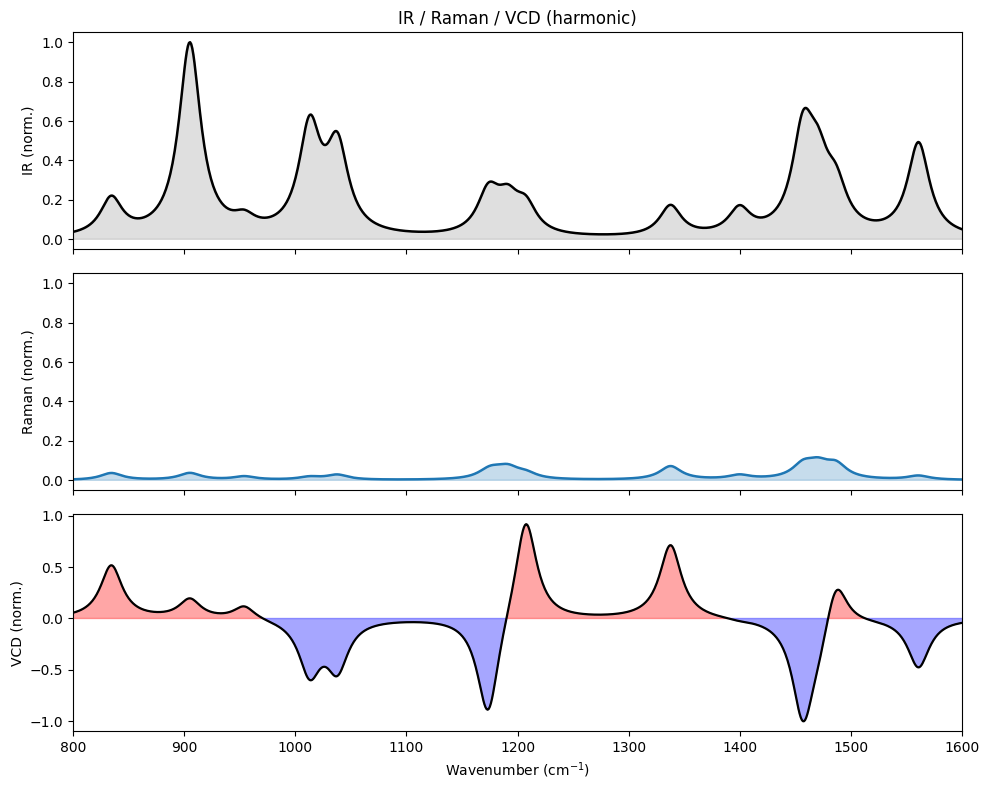

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(freq_axis, ir_n, lw=1.8, color="black")
axes[0].fill_between(freq_axis, 0, ir_n, alpha=0.25, color="gray")
axes[0].set_ylabel("IR (norm.)")
axes[0].set_title("IR / Raman / VCD (harmonic)")

axes[1].plot(freq_axis, raman_n, lw=1.8, color="tab:blue")
axes[1].fill_between(freq_axis, 0, raman_n, alpha=0.25, color="tab:blue")
axes[1].set_ylabel("Raman (norm.)")

axes[2].plot(freq_axis, vcd_n, lw=1.6, color="k")
axes[2].fill_between(freq_axis, 0, vcd_n, where=(vcd_n >= 0), color="red", alpha=0.35)
axes[2].fill_between(freq_axis, 0, vcd_n, where=(vcd_n < 0), color="blue", alpha=0.35)
axes[2].set_ylabel("VCD (norm.)")
axes[2].set_xlabel(r"Wavenumber (cm$^{-1}$)")

# # usual spectroscopy convention
for ax in axes:
    ax.invert_xaxis()
    # ax.grid(alpha=0.2)
    ax.set_xlim(1600, 800)



plt.tight_layout()

plt.savefig("test_b.pdf", bbox_inches="tight")
plt.show()

# MD spectra

In [10]:
from mmml.spectra.spectra_md import (
    extract_properties,
    compute_magnetic_dipoles,
    autocorrelation,
    cross_correlation,
    correlation_to_spectrum,
    compute_polarizability_batched,
    polarizability_autocorrelation,
    raman_to_spectrum,
)

In [11]:
EF = np.array([0,0,0])


CONFIG = "/scicore/home/meuwly/boitti0000/ckpts/propox_ef_ptT_run2/config-cd423da4-7e03-44f5-b149-5c19d583e011.json"
PARAMS = "/scicore/home/meuwly/boitti0000/ckpts/propox_ef_ptT_run2/params-cd423da4-7e03-44f5-b149-5c19d583e011.json"
calc = AseCalculatorEF(
    PARAMS,
    config_path=CONFIG,
    electric_field=EF,  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)
print(calc)

In [ ]:
frames = ase.io.read("md01.traj", index=":")

In [90]:

FIELD_SCALE = 100
calc = AseCalculatorEF(PARAMS, config_path=CONFIG, electric_field=[0.1,0.000,0.000],
                       field_scale=FIELD_SCALE)
pos, vel, mu, q = extract_properties(
    frames, calc=calc,
    recompute_dipole=False,   # True if no ml_dipole in traj
    recompute_charges=True,  # True if no ml_charges (needed for VCD)
     batch_size=64,  
)


    GPU-batched property extraction (batch_size=64, T=100001) ...
      chunk 1/1563
      chunk 156/1563
      chunk 312/1563
      chunk 468/1563
      chunk 624/1563
      chunk 780/1563
      chunk 936/1563
      chunk 1092/1563
      chunk 1248/1563
      chunk 1404/1563
      chunk 1560/1563
      Done in 11.64 s


In [91]:
dt_fs = 1.0  # 0.5 fs * write interval 10

m = compute_magnetic_dipoles(pos, vel, q)
acf_mu = autocorrelation(mu)
ccf_vm = cross_correlation(mu, m)
freq, ir = correlation_to_spectrum(acf_mu, dt_fs)
_, vcd = correlation_to_spectrum(ccf_vm, dt_fs)

freq_cm, ir = correlation_to_spectrum(acf_mu, dt_fs, window="hann", zero_pad=4)
_, vcd = correlation_to_spectrum(ccf_vm, dt_fs, window="hann", zero_pad=4)


In [92]:
ir_smooth

array([0.09732891, 0.09965689, 0.10196439, ..., 0.01084671, 0.01054084,
       0.01023723], shape=(45569,))

In [93]:
freq_p

array([ 200.05306556,  200.13645575,  200.21984594, ..., 3999.81045844,
       3999.89384863, 3999.97723882], shape=(45569,))

Trajectory: 100001 frames, 100.0 ps


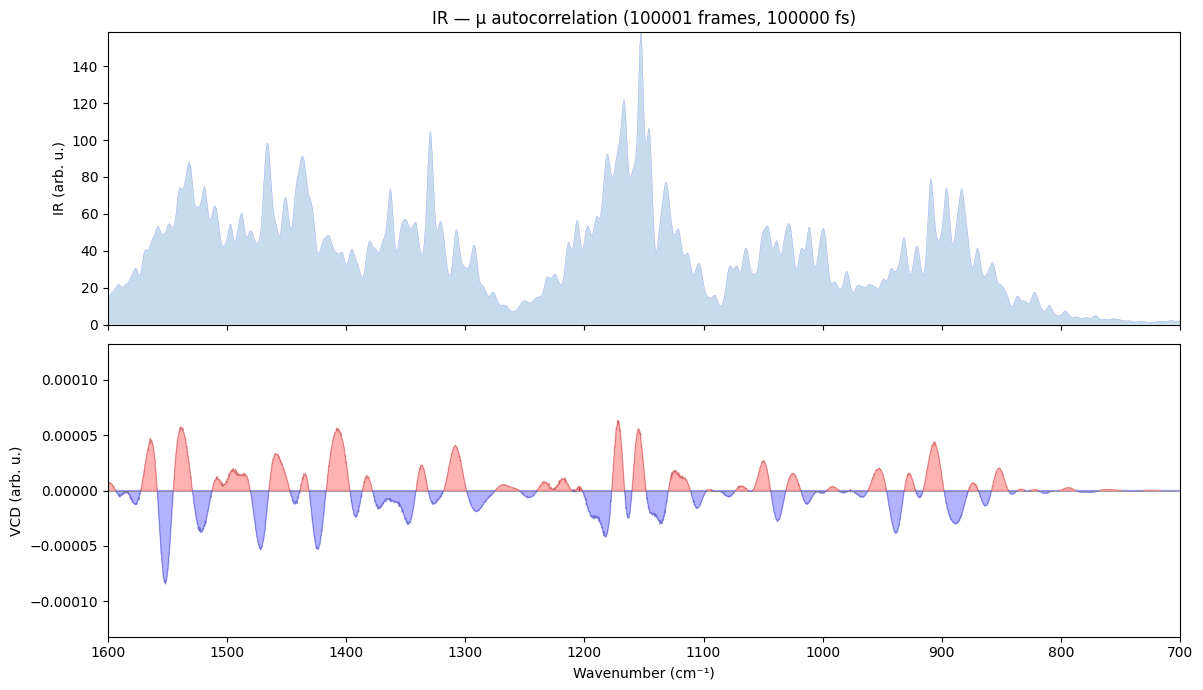

In [102]:
from mmml.spectra.spectra_md import _freq_mask

# Optional: limit frequency range (e.g. 800–1800 cm⁻¹)
mask = _freq_mask(freq_cm, 200.0, 4000.0)
freq_p = freq_cm[mask]
ir_p = ir[mask]
vcd_p = vcd[mask]
T = len(mu)
total_fs = (T - 1) * dt_fs
print(f"Trajectory: {T} frames, {total_fs/1000:.1f} ps")


from scipy.ndimage import gaussian_filter1d
def smooth_gaussian(y, freq, fwhm_cm=20.0):
    """Smooth spectrum y(freq) with Gaussian kernel; fwhm_cm in cm⁻¹."""
    df = np.median(np.diff(freq))
    sigma_pts = (fwhm_cm / 2.355) / df
    return gaussian_filter1d(y, sigma=sigma_pts, mode="nearest")
ir_smooth = smooth_gaussian(abs(ir_p), freq_p, fwhm_cm=5.0)
vcd_smooth = smooth_gaussian(vcd_p, freq_p, fwhm_cm=15.0)



# def lorentzian(x, x0, gamma):
#     return gamma / (np.pi * ((x - x0) ** 2 + gamma**2))
# def smooth_lorentzian(y, freq, hwhm_cm=15.0):
#     """Convolve spectrum with Lorentzian of HWHM hwhm_cm."""
#     df = np.median(np.diff(freq))
#     n = int(8 * hwhm_cm / df)
#     x = np.arange(-n, n + 1) * df
#     kernel = lorentzian(x, 0.0, hwhm_cm)
#     kernel /= kernel.sum()
#     return np.convolve(y, kernel, mode="same")

# ir_smooth = smooth_lorentzian(abs(ir_p), freq_p, hwhm_cm=2.0)
# vcd_smooth = smooth_lorentzian(vcd_p, freq_p, hwhm_cm=15.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(freq_p, abs(ir_smooth), "b-", lw=0.08)
ax1.fill_between(freq_p, abs(ir_smooth), alpha=0.25)
ax1.set_ylabel("IR (arb. u.)")
ax1.set_title(f"IR — μ autocorrelation ({T} frames, {total_fs:.0f} fs)")
ax1.invert_xaxis()

ax2.plot(freq_p, vcd_smooth, "k-", lw=0.08)
ax2.fill_between(freq_p, 0, vcd_smooth, where=(vcd_smooth >= 0), color="red", alpha=0.3)
ax2.fill_between(freq_p, 0, vcd_smooth, where=(vcd_smooth < 0), color="blue", alpha=0.3)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_ylabel("VCD (arb. u.)")
ax2.set_xlabel("Wavenumber (cm⁻¹)")
ax2.invert_xaxis()

plt.tight_layout()

for ax in [ax1, ax2]:
    ax.set_xlim(1600, 700)
SCALE = 1
ax1.set_ylim(0, max(abs(ir_smooth))/(SCALE))
SCALE = 10
ax2.set_ylim(-max(abs(vcd_smooth)) / SCALE, max(abs(vcd_smooth))/SCALE)
plt.show()

In [28]:
# import matplotlib.pyplot as plt

# run_index = 1

# atoms = io.read("hper_a.xyz")
# calc = AseCalculatorEF(
#     runs[run_index]["params"],
#     config_path=runs[run_index]["config"],
#     electric_field=[0,0,0],  # optional default field (model input units)
#     field_scale=100,  # E_physical [au] = E_input * field_scale
# )
# atoms.calc = calc

# alpha = calc.get_property("polarizability", atoms)
# plt.matshow(alpha, vmin=-.1, vmax=.1, cmap="coolwarm")
# plt.colorbar()
# plt.show()

# import numpy as np
# d = np.load("out/hper_a.npz", allow_pickle=True)
# alpha_true = d["polarizability"]  # shape depends on gpu4pyscf (usually 3×3)

# plt.imshow(alpha_true / 184, vmin=-.1, vmax=.1, cmap="coolwarm")
# plt.colorbar()

# plt.show()

# atoms = io.read("hper_b.xyz")


# calc = AseCalculatorEF(
#     runs[run_index]["params"],
#     config_path=runs[run_index]["config"],
#     electric_field=[0,0,0],  # optional default field (model input units)
#     field_scale=100,  # E_physical [au] = E_input * field_scale
# )

# atoms.calc = calc

# alphab = calc.get_property("polarizability", atoms)
# plt.matshow(alphab, vmin=-.1, vmax=.1, cmap="coolwarm")
# plt.colorbar()

# plt.show()

# import numpy as np
# d = np.load("out/hper_b.npz", allow_pickle=True)
# alpha_trueb = d["polarizability"]  # shape depends on gpu4pyscf (usually 3×3)

# plt.imshow(alpha_trueb / 184, vmin=-.1, vmax=.1, cmap="coolwarm")
# plt.colorbar()

# plt.show()


# plt.scatter(alpha_true.flatten() / 184, alpha.flatten())
# plt.scatter(alpha_trueb.flatten() / 184, alphab.flatten())
# plt.plot([0,1],[0,1],transform=plt.gca().transAxes, color="k")


# X = np.concatenate([alpha_true.flatten() / 184, alpha_trueb.flatten() / 184])
# y = np.concatenate([alpha.flatten() / 1, alphab.flatten() / 1])
# # plt.scatter(alpha_trueb.flatten()  alphab.flatten())
# mae = np.mean(np.abs(X - y))
# rmse = np.sqrt(np.mean((X - y)**2))


# plt.title((mae * 184, rmse * 184))
# plt.show()